# Sentiment Panel Regression — Placebo Test

Placebo/falsification test: lagged returns (t-1 to t0) are used to predict future sentiment (t0 to t+1). If sentiment has predictive power over returns but not vice versa, this supports the validity of the main results.

In [17]:
import pandas as pd
import numpy as np
from linearmodels import PanelOLS, PooledOLS
from linearmodels.panel import RandomEffects
from pathlib import Path

## Config

| `LAG_WINDOW` | Sentiment window | Target return |
|---|---|---|
| `'daily'` | posts on day D-1 | return on day D |
| `'weekly'` | mean of posts in week W-1 | compound return in week W |
| `'monthly'` | mean of posts in month M-1 | compound return in month M |


In [18]:
LAG_WINDOW          = 'weekly'   # 'daily' | 'weekly' | 'monthly'
NULL_STRATEGY       = 'drop'

PANEL_DATA_PATH  = Path('./data/panel_data.parquet')
SENTIMENT_PATH   = Path('../sentiment/data/all_labeled_finnishbert.parquet')
FORUM_POSTS_PATH = Path('../sentiment/data/cleaned_forum_posts.parquet')

print(f'LAG_WINDOW          : {LAG_WINDOW}')

LAG_WINDOW          : weekly


## Load Data

In [19]:
stock_daily = pd.read_parquet(PANEL_DATA_PATH)
stock_daily['Date'] = pd.to_datetime(stock_daily['Date'])
if 'prev_day_sentiment' in stock_daily.columns:
    stock_daily = stock_daily.drop(columns=['prev_day_sentiment'])

sentiment   = pd.read_parquet(SENTIMENT_PATH,   columns=['id', 'sentiment'])
forum_posts = pd.read_parquet(FORUM_POSTS_PATH, columns=['id', 'date_time', 'ticker'])

print(f'Stock rows : {len(stock_daily):,}  |  tickers: {stock_daily["ticker"].nunique()}')
print(f'Sentiment  : {len(sentiment):,}')

Stock rows : 390,127  |  tickers: 162
Sentiment  : 532,424


## Resample Stock Data & Compute Controls

For weekly/monthly specs, daily returns are compounded into period returns and control variables are aggregated to the same frequency. Daily-lag controls (`return_lag1/2/5`) are replaced by a single `return_lag_period` computed from the resampled panel.

In [20]:
# Column classification for aggregation
COMPOUND_COLS = [
    'return',
    'open_to_close_return', 'close_to_open_return',
    'EURUSD_return', 'EURSEK_return', 'EURCNY_return',
    'GC_return', 'CL_return', 'VIX_return', 'GSPC_return', 'TNX_return',
    'OMXHPI_return', 'OMXN40_return', 'STOXX50E_return',
]
SUM_COLS  = ['euribor_3m_diff', 'finland_10y_diff']
MEAN_COLS = ['log_volume', 'gk_vol', 'momentum_12_1', 'amihud']
LAST_COLS = ['unemp_rate_change_lagged', 'cpi_rate_change_lagged', 'consumer_conf_change_lagged']

def compound(s):
    valid = s.dropna()
    return (1 + valid).prod() - 1 if len(valid) else np.nan


def resample_stock(df, period):
    """Resample daily panel to weekly or monthly frequency."""
    df = df.copy()
    if period == 'weekly':
        # Period key = Monday of the trading week
        df['_period'] = df['Date'] - pd.to_timedelta(df['Date'].dt.weekday, unit='D')
    else:  # monthly
        df['_period'] = df['Date'].dt.to_period('M').dt.to_timestamp()

    present = set(df.columns)
    agg = {}
    for c in COMPOUND_COLS:
        if c in present: agg[c] = compound
    for c in SUM_COLS:
        if c in present: agg[c] = 'sum'
    for c in MEAN_COLS:
        if c in present: agg[c] = 'mean'
    for c in LAST_COLS:
        if c in present: agg[c] = 'last'

    result = (
        df.groupby(['ticker', '_period'])
        .agg(agg)
        .reset_index()
        .rename(columns={'_period': 'Date'})
    )
    # Lagged period return replaces daily return_lag1/2/5
    result = result.sort_values(['ticker', 'Date'])
    result['return_lag_period'] = result.groupby('ticker')['return'].shift(1)
    return result


if LAG_WINDOW == 'daily':
    df_stock = stock_daily.copy()
    PERIOD_CONTROLS = [
        'return_lag1', 'return_lag2', 'return_lag5',
        'log_volume', 'gk_vol', 'momentum_12_1', 'amihud',
        'open_to_close_return', 'close_to_open_return',
        'EURUSD_return', 'EURSEK_return', 'EURCNY_return',
        'GC_return', 'CL_return', 'VIX_return', 'GSPC_return', 'TNX_return',
        'euribor_3m_diff', 'OMXHPI_return', 'OMXN40_return', 'STOXX50E_return',
        'finland_10y_diff', 'unemp_rate_change_lagged',
        'cpi_rate_change_lagged', 'consumer_conf_change_lagged',
    ]
else:
    df_stock = resample_stock(stock_daily, LAG_WINDOW)
    PERIOD_CONTROLS = [
        'return_lag_period',
        'log_volume', 'gk_vol', 'momentum_12_1', 'amihud',
        'EURUSD_return', 'EURSEK_return', 'EURCNY_return',
        'GC_return', 'CL_return', 'VIX_return', 'GSPC_return', 'TNX_return',
        'euribor_3m_diff', 'OMXHPI_return', 'OMXN40_return', 'STOXX50E_return',
        'finland_10y_diff', 'unemp_rate_change_lagged',
        'cpi_rate_change_lagged', 'consumer_conf_change_lagged',
    ]

print(f'Resampled stock shape: {df_stock.shape}')
print(f'Period range: {df_stock["Date"].min().date()} — {df_stock["Date"].max().date()}')

Resampled stock shape: (82846, 26)
Period range: 2012-01-02 — 2025-12-29


## Compute Sentiment Variable

In [21]:
# Attach date + ticker to each label
sent_dated = sentiment.merge(forum_posts, on='id', how='inner')
sent_dated['Date'] = sent_dated['date_time'].dt.normalize()

# Daily mean sentiment per (ticker, calendar day)
daily_sent = (
    sent_dated
    .groupby(['ticker', 'Date'])['sentiment']
    .mean()
    .reset_index()
)

if LAG_WINDOW == 'daily':
    # Infer trading days from panel data: any weekday missing stock rows is
    # treated as a holiday (covers Easter, Independence Day, etc.).
    trading_days = np.sort(df_stock['Date'].unique())  # sorted datetime64 array

    # Map each post date to the next trading day *strictly after* it.
    # This absorbs weekend/holiday posts into the following trading day's
    # lag window rather than dropping them.
    #   e.g. Fri/Sat/Sun posts → all attributed to Monday's sentiment_var
    post_dates = daily_sent['Date'].values
    idx = np.searchsorted(trading_days, post_dates, side='right')
    valid = idx < len(trading_days)
    idx_clipped = np.minimum(idx, len(trading_days) - 1)
    daily_sent['next_trading_day'] = pd.to_datetime(
        np.where(valid, trading_days[idx_clipped], pd.NaT)
    )

    # Drop posts that fall after the last trading day in the dataset
    daily_sent = daily_sent.dropna(subset=['next_trading_day'])

    # Aggregate: all posts in the lag window [prev_trading_day+1 … D-1] → D
    lag_sent = (
        daily_sent
        .groupby(['ticker', 'next_trading_day'])['sentiment']
        .mean()
        .reset_index()
        .rename(columns={'next_trading_day': 'Date'})
    )

    # Merge onto trading-day grid; no shift needed — attribution is already lagged
    all_dates = df_stock[['ticker', 'Date']].drop_duplicates()
    daily_sent = all_dates.merge(lag_sent, on=['ticker', 'Date'], how='left')
    daily_sent['sentiment_var'] = daily_sent['sentiment']

    n_on_nontrading = (~np.isin(post_dates, trading_days) & valid).sum()
    print(f'Trading days inferred : {len(trading_days):,}')
    print(f'Posts on non-trading days absorbed: {n_on_nontrading:,}')

else:
    # Aggregate posts to the same period key used in df_stock
    if LAG_WINDOW == 'weekly':
        daily_sent['_period'] = daily_sent['Date'] - pd.to_timedelta(daily_sent['Date'].dt.weekday, unit='D')
    else:  # monthly
        daily_sent['_period'] = daily_sent['Date'].dt.to_period('M').dt.to_timestamp()

    period_sent = (
        daily_sent
        .groupby(['ticker', '_period'])['sentiment']
        .mean()
        .reset_index()
        .rename(columns={'_period': 'Date'})
    )

    # Merge onto period stock grid, then shift 1 period
    all_periods = df_stock[['ticker', 'Date']].drop_duplicates()
    period_sent = all_periods.merge(period_sent, on=['ticker', 'Date'], how='left')
    period_sent = period_sent.sort_values(['ticker', 'Date'])
    period_sent['sentiment_var'] = (
        period_sent
        .groupby('ticker')['sentiment']
        .transform(lambda s: s.shift(1))  # period P-1 sentiment predicts period P return
    )
    daily_sent = period_sent

# Apply null strategy
if NULL_STRATEGY == 'neutral':
    daily_sent['sentiment_var'] = daily_sent['sentiment_var'].fillna(1.0)
elif NULL_STRATEGY == 'forward_fill':
    daily_sent['sentiment_var'] = (
        daily_sent.groupby('ticker')['sentiment_var']
        .transform(lambda s: s.ffill())
    )
# 'drop' — leave NaN; handled by dropna() in panel prep

coverage = daily_sent['sentiment_var'].notna().mean()
print(f'Sentiment coverage after "{NULL_STRATEGY}" strategy: {coverage:.1%}')
print(daily_sent['sentiment_var'].describe())

Sentiment coverage after "drop" strategy: 37.3%
count    30871.000000
mean         1.231300
std          0.553328
min          0.000000
25%          0.972222
50%          1.250000
75%          1.666667
max          2.000000
Name: sentiment_var, dtype: float64


## Build Panel Dataset

In [22]:
df = df_stock.merge(
    daily_sent[['ticker', 'Date', 'sentiment_var']],
    on=['ticker', 'Date'], how='left'
)

analysis_vars = ['return', 'sentiment_var'] + PERIOD_CONTROLS


df_panel = df.dropna(subset=analysis_vars)

df_panel = df_panel[['ticker', 'Date'] + analysis_vars].copy()
df_panel['const'] = 1.0  # explicit intercept for PooledOLS
df_panel = df_panel.set_index(['ticker', 'Date'])

print(f'Panel rows : {len(df_panel):,}')
print(f'Tickers    : {df_panel.index.get_level_values(0).nunique()}')
print(f'Periods    : {df_panel.index.get_level_values(1).nunique()}')

Panel rows : 29,294
Tickers    : 153
Periods    : 674


## 1. Pooled OLS (Baseline)

## 1b. Hausman Test (FE vs RE)

In [23]:
df_panel['sentiment_lead'] = df_panel.groupby(level='ticker')['sentiment_var'].shift(-1)
df_panel = df_panel.dropna(subset=['sentiment_lead'])

exog_vars       = ['return'] + PERIOD_CONTROLS
exog_vars_const = ['const'] + exog_vars  # PooledOLS needs explicit intercept

re_results = RandomEffects(df_panel['sentiment_lead'], df_panel[exog_vars]).fit(
    cov_type='unadjusted'  # Hausman requires unadjusted (classical) SEs on both models
)
fe_hausman = PanelOLS(df_panel['sentiment_lead'], df_panel[exog_vars], entity_effects=True).fit(
    cov_type='unadjusted'
)

# Hausman statistic: H = (b_FE - b_RE)' * [Var(b_FE) - Var(b_RE)]^-1 * (b_FE - b_RE)
# Under H0 (RE consistent & efficient), H ~ chi2(k)
b_fe = fe_hausman.params.values
b_re = re_results.params[fe_hausman.params.index].values

v_fe = fe_hausman.cov.values
v_re = re_results.cov.loc[fe_hausman.params.index, fe_hausman.params.index].values

diff = b_fe - b_re
v_diff = v_fe - v_re

try:
    import numpy.linalg as la
    H = float(diff @ la.pinv(v_diff) @ diff)
    k = len(diff)
    from scipy import stats
    p_hausman = float(1 - stats.chi2.cdf(H, df=k))

    print('=' * 60)
    print('HAUSMAN TEST  (H0: RE is consistent — use RE)')
    print('=' * 60)
    print(f'Chi2 statistic : {H:.4f}')
    print(f'Degrees of freedom: {k}')
    print(f'p-value        : {p_hausman:.4f}')
    if p_hausman < 0.05:
        print('Verdict: Reject H0 → FE preferred (entity effects correlated with regressors)')
    else:
        print('Verdict: Fail to reject H0 → RE may be appropriate')
except np.linalg.LinAlgError as e:
    print(f'Hausman test failed (singular variance matrix): {e}')

print()
print('RE model summary (for reference):')
print(re_results.summary)

HAUSMAN TEST  (H0: RE is consistent — use RE)
Chi2 statistic : 266.2960
Degrees of freedom: 22
p-value        : 0.0000
Verdict: Reject H0 → FE preferred (entity effects correlated with regressors)

RE model summary (for reference):
                        RandomEffects Estimation Summary                        
Dep. Variable:         sentiment_lead   R-squared:                        0.1102
Estimator:              RandomEffects   R-squared (Between):              0.8704
No. Observations:               29141   R-squared (Within):               0.0152
Date:                Tue, Apr 21 2026   R-squared (Overall):              0.7715
Time:                        14:41:11   Log-likelihood                  -2.3e+04
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      163.94
Entities:                         153   P-value                           0.0000
Avg Obs:                       190.46  

In [24]:
pooled_results = PooledOLS(df_panel['sentiment_lead'], df_panel[exog_vars_const]).fit(
    cov_type='clustered', cluster_entity=True
)
print('=' * 80)
print('POOLED OLS (Baseline — No Panel Effects)')
print('=' * 80)
print(pooled_results.summary)

POOLED OLS (Baseline — No Panel Effects)
                          PooledOLS Estimation Summary                          
Dep. Variable:         sentiment_lead   R-squared:                        0.0416
Estimator:                  PooledOLS   R-squared (Between):              0.0664
No. Observations:               29141   R-squared (Within):               0.0336
Date:                Tue, Apr 21 2026   R-squared (Overall):              0.0416
Time:                        14:41:12   Log-likelihood                -2.345e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      57.396
Entities:                         153   P-value                           0.0000
Avg Obs:                       190.46   Distribution:                F(22,29118)
Min Obs:                       1.0000                                           
Max Obs:                       555.00   F-statistic (robust):       

## 2. Entity Fixed Effects

In [25]:
fe_results = PanelOLS(df_panel['sentiment_lead'], df_panel[exog_vars], entity_effects=True).fit(
    cov_type='clustered', cluster_entity=True
)
print('=' * 80)
print('ENTITY FIXED EFFECTS')
print('=' * 80)
print(fe_results.summary)

# Wooldridge-style test for serial autocorrelation in panel residuals
import statsmodels.formula.api as smf
resid = fe_results.resids.rename('resid')
resid_lag = resid.groupby(level='ticker').shift(1).rename('resid_lag')
resid_df = pd.concat([resid, resid_lag], axis=1).dropna().reset_index()
wr = smf.ols('resid ~ resid_lag', data=resid_df).fit(
    cov_type='cluster', cov_kwds={'groups': resid_df['ticker']}
)
print('\nWooldridge-style autocorrelation test (H0: no serial autocorrelation):')
print(f'  coef(resid_lag) = {wr.params["resid_lag"]:.4f},  p = {wr.pvalues["resid_lag"]:.4f}  {"→ autocorrelation present" if wr.pvalues["resid_lag"] < 0.05 else "→ no evidence of autocorrelation"}')

ENTITY FIXED EFFECTS
                          PanelOLS Estimation Summary                           
Dep. Variable:         sentiment_lead   R-squared:                        0.0345
Estimator:                   PanelOLS   R-squared (Between):             -0.0687
No. Observations:               29141   R-squared (Within):               0.0345
Date:                Tue, Apr 21 2026   R-squared (Overall):             -0.0377
Time:                        14:41:12   Log-likelihood                 -2.25e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      46.977
Entities:                         153   P-value                           0.0000
Avg Obs:                       190.46   Distribution:                F(22,28966)
Min Obs:                       1.0000                                           
Max Obs:                       555.00   F-statistic (robust):             16.171
       

## 3. Two-Way Fixed Effects (Entity + Time)

In [26]:
fe_time_results = PanelOLS(
    df_panel['sentiment_lead'], df_panel[exog_vars],
    entity_effects=True, time_effects=True, drop_absorbed=True
).fit(cov_type='clustered', cluster_entity=True)

print('=' * 80)
print('TWO-WAY FIXED EFFECTS (Entity + Time FE)')
print('=' * 80)
print(fe_time_results.summary)

TWO-WAY FIXED EFFECTS (Entity + Time FE)
                          PanelOLS Estimation Summary                           
Dep. Variable:         sentiment_lead   R-squared:                        0.0272
Estimator:                   PanelOLS   R-squared (Between):             -4.8894
No. Observations:               29141   R-squared (Within):              -50.490
Date:                Tue, Apr 21 2026   R-squared (Overall):             -10.509
Time:                        14:41:12   Log-likelihood                -2.206e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      35.997
Entities:                         153   P-value                           0.0000
Avg Obs:                       190.46   Distribution:                F(22,28294)
Min Obs:                       1.0000                                           
Max Obs:                       555.00   F-statistic (robust):       

## 4. F-test for Entity Effects

In [27]:
from scipy import stats

# F-test for entity fixed effects (H0: Pooled OLS is adequate)
print('F-test for entity fixed effects:')
print('H0: Pooled OLS is appropriate (no entity effects)')
print('H1: Entity fixed effects are warranted')
try:
    f_stat = fe_results.f_pooled.stat
    f_pval = fe_results.f_pooled.pval
    print(f'  F-stat : {f_stat:.4f}')
    print(f'  p-value: {f_pval:.4f}')
    print('  Verdict:', 'Reject H0 — entity FE warranted' if f_pval < 0.05 else 'Fail to reject H0')
except Exception as e:
    print(f'  Could not compute F-test: {e}')

# F-test for time fixed effects (H0: Entity FE is sufficient, no time effects)
print('\nF-test for time fixed effects:')
print('H0: Entity FE is sufficient (no time effects)')
print('H1: Two-Way FE is warranted')
try:
    n      = fe_results.nobs
    k_extra = fe_time_results.df_model - fe_results.df_model
    rss_r  = fe_results.resid_ss
    rss_u  = fe_time_results.resid_ss
    denom_df = n - fe_time_results.df_model - 1
    f_time = ((rss_r - rss_u) / k_extra) / (rss_u / denom_df)
    p_time = stats.f.sf(f_time, k_extra, denom_df)
    print(f'  F-stat : {f_time:.4f}')
    print(f'  p-value: {p_time:.4f}')
    print('  Verdict:', 'Reject H0 — Two-Way FE warranted' if p_time < 0.05 else 'Fail to reject H0 — Entity FE sufficient')
except Exception as e:
    print(f'  Could not compute F-test: {e}')


F-test for entity fixed effects:
H0: Pooled OLS is appropriate (no entity effects)
H1: Entity fixed effects are warranted
  F-stat : 12.8816
  p-value: 0.0000
  Verdict: Reject H0 — entity FE warranted

F-test for time fixed effects:
H0: Entity FE is sufficient (no time effects)
H1: Two-Way FE is warranted
  F-stat : 1.2966
  p-value: 0.0000
  Verdict: Reject H0 — Two-Way FE warranted


## 5. Return Dummies (Entity FE + Two-Way FE, ref = zero return)

In [28]:
df_dum = df_panel.copy()
df_dum['ret_negative'] = (df_dum['return'] < 0).astype(float)
df_dum['ret_positive'] = (df_dum['return'] > 0).astype(float)

exog_dummies = ['ret_negative', 'ret_positive'] + PERIOD_CONTROLS

fe_dummy_results = PanelOLS(df_dum['sentiment_lead'], df_dum[exog_dummies], entity_effects=True).fit(
    cov_type='clustered', cluster_entity=True
)
print('=' * 80)
print('ENTITY FE — RETURN DUMMIES (ref: zero return)')
print('=' * 80)
print(fe_dummy_results.summary)

fe_time_dummy_results = PanelOLS(
    df_dum['sentiment_lead'], df_dum[exog_dummies],
    entity_effects=True, time_effects=True, drop_absorbed=True
).fit(cov_type='clustered', cluster_entity=True)
print('=' * 80)
print('TWO-WAY FE — RETURN DUMMIES (ref: zero return)')
print('=' * 80)
print(fe_time_dummy_results.summary)


ENTITY FE — RETURN DUMMIES (ref: zero return)
                          PanelOLS Estimation Summary                           
Dep. Variable:         sentiment_lead   R-squared:                        0.0295
Estimator:                   PanelOLS   R-squared (Between):             -0.0004
No. Observations:               29141   R-squared (Within):               0.0295
Date:                Tue, Apr 21 2026   R-squared (Overall):              0.0190
Time:                        14:41:12   Log-likelihood                -2.257e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      38.336
Entities:                         153   P-value                           0.0000
Avg Obs:                       190.46   Distribution:                F(23,28965)
Min Obs:                       1.0000                                           
Max Obs:                       555.00   F-statistic (robust):  

## 6. Piecewise Continuous Return (Entity FE + Two-Way FE)

In [29]:
df_pw = df_panel.copy()
# Negative branch: magnitude of negative return (0 when zero/positive)
df_pw['ret_neg_cont'] = np.where(df_pw['return'] < 0, np.abs(df_pw['return']), 0.0)
# Positive branch: magnitude of positive return (0 when zero/negative)
df_pw['ret_pos_cont'] = np.where(df_pw['return'] > 0, df_pw['return'], 0.0)

exog_pw = ['ret_neg_cont', 'ret_pos_cont'] + PERIOD_CONTROLS

fe_pw_results = PanelOLS(df_pw['sentiment_lead'], df_pw[exog_pw], entity_effects=True).fit(
    cov_type='clustered', cluster_entity=True
)
print('=' * 80)
print('ENTITY FE — PIECEWISE CONTINUOUS RETURN')
print('=' * 80)
print(fe_pw_results.summary)

fe_pw_time_results = PanelOLS(
    df_pw['sentiment_lead'], df_pw[exog_pw],
    entity_effects=True, time_effects=True, drop_absorbed=True
).fit(cov_type='clustered', cluster_entity=True)
print('=' * 80)
print('TWO-WAY FE — PIECEWISE CONTINUOUS RETURN')
print('=' * 80)
print(fe_pw_time_results.summary)


ENTITY FE — PIECEWISE CONTINUOUS RETURN
                          PanelOLS Estimation Summary                           
Dep. Variable:         sentiment_lead   R-squared:                        0.0351
Estimator:                   PanelOLS   R-squared (Between):             -0.0348
No. Observations:               29141   R-squared (Within):               0.0351
Date:                Tue, Apr 21 2026   R-squared (Overall):             -0.0077
Time:                        14:41:12   Log-likelihood                -2.249e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      45.762
Entities:                         153   P-value                           0.0000
Avg Obs:                       190.46   Distribution:                F(23,28965)
Min Obs:                       1.0000                                           
Max Obs:                       555.00   F-statistic (robust):        

## 7. Summary

In [30]:
print('=' * 80)
print('P-VALUE SUMMARY — PLACEBO TEST (lagged return → future sentiment)')
print('=' * 80)

def sig(p):
    if p < 0.01: return '***'
    if p < 0.05: return '**'
    if p < 0.10: return '*'
    return 'n.s.'

# Continuous return
rows = []
if 'return' in fe_time_results.params.index:
    p    = fe_time_results.params['return']
    se   = fe_time_results.std_errors['return']
    pval = fe_time_results.pvalues['return']
    rows.append({'Model': 'Two-Way FE', 'Coef': round(p, 6), 'Std Err': round(se, 6),
                 'p-value': round(pval, 4), 'Sig': sig(pval)})
else:
    rows.append({'Model': 'Two-Way FE', 'Coef': None, 'Std Err': None,
                 'p-value': None, 'Sig': 'absorbed'})

print('Continuous return:')
print(pd.DataFrame(rows).set_index('Model').to_string())

print('\nReturn dummies — Two-Way FE (ref=zero return):')
for var in ['ret_negative', 'ret_positive']:
    if var in fe_time_dummy_results.params.index:
        coef = fe_time_dummy_results.params[var]
        pval = fe_time_dummy_results.pvalues[var]
        print(f'  {var:15s}  coef={coef:.6f}  p={pval:.4f}  {sig(pval)}')
    else:
        print(f'  {var:15s}  absorbed by time FE')

print('\nPiecewise continuous return — Two-Way FE:')
for var in ['ret_neg_cont', 'ret_pos_cont']:
    if var in fe_pw_time_results.params.index:
        coef = fe_pw_time_results.params[var]
        pval = fe_pw_time_results.pvalues[var]
        print(f'  {var:15s}  coef={coef:.6f}  p={pval:.4f}  {sig(pval)}')
    else:
        print(f'  {var:15s}  absorbed by time FE')


P-VALUE SUMMARY — PLACEBO TEST (lagged return → future sentiment)
Continuous return:
                Coef   Std Err  p-value  Sig
Model                                       
Two-Way FE  1.133251  0.072951      0.0  ***

Return dummies — Two-Way FE (ref=zero return):
  ret_negative     coef=-0.148199  p=0.2856  n.s.
  ret_positive     coef=-0.045111  p=0.7450  n.s.

Piecewise continuous return — Two-Way FE:
  ret_neg_cont     coef=-1.590578  p=0.0000  ***
  ret_pos_cont     coef=0.825736  p=0.0000  ***


## Residual Autocorrelation Diagnostics — Placebo Test

ACF/PACF of TWFE residuals (entity-averaged) to visually inspect for serial autocorrelation.

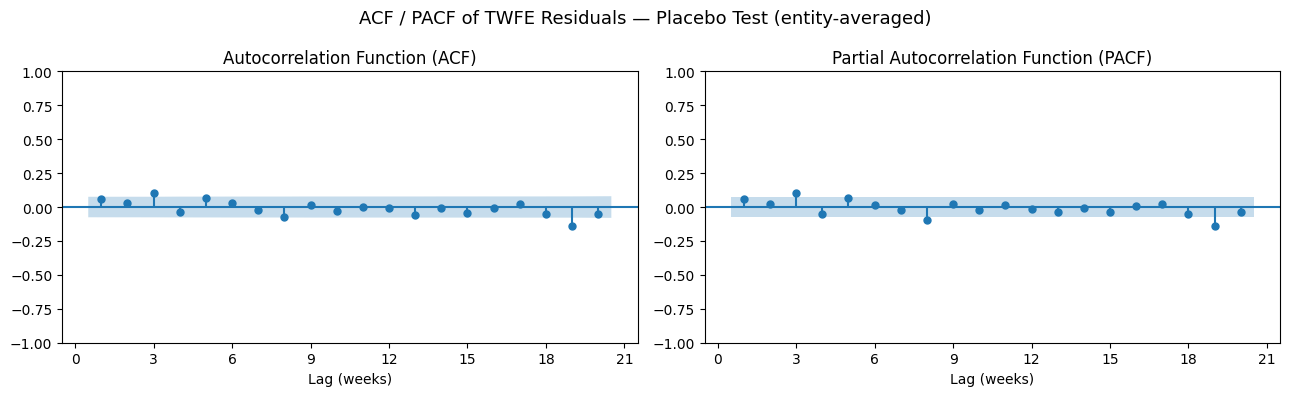

Time periods: 673, max lags plotted: 20


In [31]:
import statsmodels.graphics.tsaplots as tsaplots
import matplotlib.pyplot as plt

resids = fe_time_results.resids
mean_resids = resids.groupby(level='Date').mean().sort_index()

n_periods = len(mean_resids)
max_lags = min(20, n_periods // 2 - 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('ACF / PACF of TWFE Residuals — Placebo Test (entity-averaged)', fontsize=13)

tsaplots.plot_acf(mean_resids, lags=max_lags, ax=axes[0], alpha=0.05, zero=False)
axes[0].set_title('Autocorrelation Function (ACF)')
axes[0].set_xlabel('Lag (weeks)')
axes[0].xaxis.set_major_locator(plt.MaxNLocator(integer=True))

tsaplots.plot_pacf(mean_resids, lags=max_lags, ax=axes[1], alpha=0.05, method='ywm', zero=False)
axes[1].set_title('Partial Autocorrelation Function (PACF)')
axes[1].set_xlabel('Lag (weeks)')
axes[1].xaxis.set_major_locator(plt.MaxNLocator(integer=True))

plt.tight_layout()
plt.show()

print(f'Time periods: {n_periods}, max lags plotted: {max_lags}')

## Robustness: Driscoll-Kraay Standard Errors

Driscoll-Kraay SEs are robust to heteroskedasticity, serial autocorrelation, and cross-sectional dependence (common shocks across firms). Reported alongside clustered SEs for comparison.

In [32]:
import numpy as np
import pandas as pd

T = df_panel.index.get_level_values('Date').nunique()
bw = int(np.floor(T ** 0.25))
print(f'Time periods T={T}, Driscoll-Kraay bandwidth={bw}')

# TWFE: continuous return
twfe_dk = PanelOLS(
    df_panel['sentiment_lead'], df_panel[exog_vars],
    entity_effects=True, time_effects=True, drop_absorbed=True
).fit(cov_type='driscoll-kraay', bandwidth=bw)

# TWFE: return dummies
twfe_dum_dk = PanelOLS(
    df_dum['sentiment_lead'], df_dum[exog_dummies],
    entity_effects=True, time_effects=True, drop_absorbed=True
).fit(cov_type='driscoll-kraay', bandwidth=bw)

# TWFE: piecewise continuous return
twfe_pw_dk = PanelOLS(
    df_pw['sentiment_lead'], df_pw[exog_pw],
    entity_effects=True, time_effects=True, drop_absorbed=True
).fit(cov_type='driscoll-kraay', bandwidth=bw)

def compare_row(label, var, clustered, dk):
    if var not in clustered.params.index:
        return None
    return {
        'Model': label,
        'Variable': var,
        'Coef': round(clustered.params[var], 6),
        'SE (clustered)': round(clustered.std_errors[var], 6),
        'p (clustered)': round(clustered.pvalues[var], 4),
        'SE (DK)': round(dk.std_errors[var], 6),
        'p (DK)': round(dk.pvalues[var], 4),
    }

rows = [
    compare_row('TWFE continuous', 'return',       fe_time_results,       twfe_dk),
    compare_row('TWFE dummies',    'ret_negative', fe_time_dummy_results, twfe_dum_dk),
    compare_row('TWFE dummies',    'ret_positive', fe_time_dummy_results, twfe_dum_dk),
    compare_row('TWFE piecewise',  'ret_neg_cont', fe_pw_time_results,    twfe_pw_dk),
    compare_row('TWFE piecewise',  'ret_pos_cont', fe_pw_time_results,    twfe_pw_dk),
]
rows = [r for r in rows if r is not None]

print('\nClustered vs Driscoll-Kraay SE comparison (TWFE placebo models):')
print(pd.DataFrame(rows).to_string(index=False))


Time periods T=673, Driscoll-Kraay bandwidth=5

Clustered vs Driscoll-Kraay SE comparison (TWFE placebo models):
          Model     Variable      Coef  SE (clustered)  p (clustered)  SE (DK)  p (DK)
TWFE continuous       return  1.133251        0.072951         0.0000 0.061927  0.0000
   TWFE dummies ret_negative -0.148199        0.138796         0.2856 0.112320  0.1870
   TWFE dummies ret_positive -0.045111        0.138680         0.7450 0.112397  0.6882
 TWFE piecewise ret_neg_cont -1.590578        0.139049         0.0000 0.120414  0.0000
 TWFE piecewise ret_pos_cont  0.825736        0.097707         0.0000 0.090982  0.0000
